Import the Required Libraries

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Graph Style
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


Read the Dataset

In [2]:
# ==========================================
# Load the Datasets
# ==========================================

application = pd.read_csv('/content/application_record.csv')

credit = pd.read_csv('/content/credit_record.csv')

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
print("Application Dataset Shape :", application.shape)

print("Credit Dataset Shape :", credit.shape)

Application Dataset Shape : (110084, 18)
Credit Dataset Shape : (1048575, 3)


In [6]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110084 entries, 0 to 110083
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   110084 non-null  int64  
 1   CODE_GENDER          110084 non-null  object 
 2   FLAG_OWN_CAR         110084 non-null  object 
 3   FLAG_OWN_REALTY      110084 non-null  object 
 4   CNT_CHILDREN         110084 non-null  int64  
 5   AMT_INCOME_TOTAL     110084 non-null  float64
 6   NAME_INCOME_TYPE     110084 non-null  object 
 7   NAME_EDUCATION_TYPE  110084 non-null  object 
 8   NAME_FAMILY_STATUS   110084 non-null  object 
 9   NAME_HOUSING_TYPE    110084 non-null  object 
 10  DAYS_BIRTH           110084 non-null  int64  
 11  DAYS_EMPLOYED        110084 non-null  int64  
 12  FLAG_MOBIL           110084 non-null  int64  
 13  FLAG_WORK_PHONE      110084 non-null  int64  
 14  FLAG_PHONE           110084 non-null  int64  
 15  FLAG_EMAIL       

In [7]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [8]:
application.describe(include='all')

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
count,1.100840e+05,110084,110084,110084,110084.000000,1.100840e+05,110084,110084,110084,110084,110084.000000,110084.000000,110084.0,110084.000000,110084.000000,110084.000000,75749,110083.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,Laborers,NaN
freq,NaN,74432,68639,73378,NaN,NaN,55979,75084,75443,99062,NaN,NaN,NaN,NaN,NaN,NaN,19097,NaN
mean,5.380797e+06,NaN,NaN,NaN,0.435104,1.859653e+05,NaN,NaN,NaN,NaN,-16045.811226,62489.308101,1.0,0.217888,0.298872,0.083009,NaN,2.203764
std,4.007288e+05,NaN,NaN,NaN,0.739250,1.044108e+05,NaN,NaN,NaN,NaN,4206.744139,140416.150761,0.0,0.412813,0.457766,0.275898,NaN,0.910556
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.700000e+04,NaN,NaN,NaN,NaN,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,NaN,1.000000
25%,5.115960e+06,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,-19548.000000,-3088.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
50%,5.267787e+06,NaN,NaN,NaN,0.000000,1.575000e+05,NaN,NaN,NaN,NaN,-15593.500000,-1491.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
75%,5.429303e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12530.000000,-361.000000,1.0,0.000000,1.000000,0.000000,NaN,3.000000


In [9]:
credit.describe(include='all')

,ID,MONTHS_BALANCE,STATUS
count,1.048575e+06,1.048575e+06,1048575
unique,NaN,NaN,8
top,NaN,NaN,C
freq,NaN,NaN,442031
mean,5.068286e+06,-1.913700e+01,NaN
std,4.615058e+04,1.402350e+01,NaN
min,5.001711e+06,-6.000000e+01,NaN
25%,5.023644e+06,-2.900000e+01,NaN
50%,5.062104e+06,-1.700000e+01,NaN
75%,5.113856e+06,-7.000000e+00,NaN


In [10]:
application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [11]:
credit.isnull().sum()

,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [12]:
application.duplicated().sum()

np.int64(0)

In [13]:
credit.duplicated().sum()

np.int64(0)

Univariate Analysis

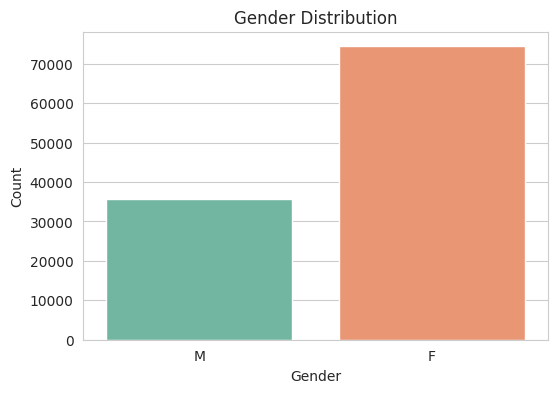

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=application, x='CODE_GENDER', palette='Set2')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

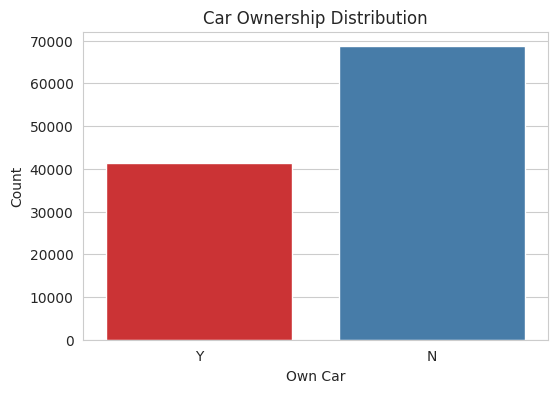

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=application, x='FLAG_OWN_CAR', palette='Set1')

plt.title("Car Ownership Distribution")
plt.xlabel("Own Car")
plt.ylabel("Count")

plt.show()

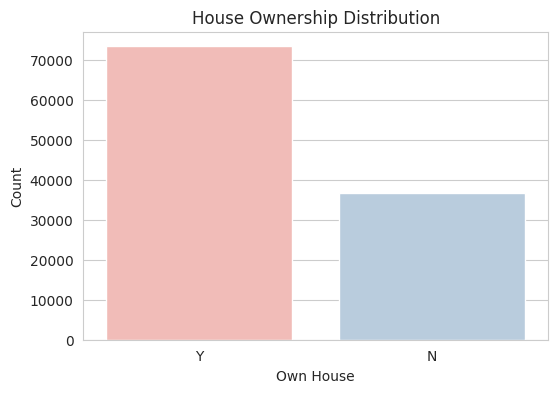

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=application, x='FLAG_OWN_REALTY', palette='Pastel1')

plt.title("House Ownership Distribution")

plt.xlabel("Own House")

plt.ylabel("Count")

plt.show()

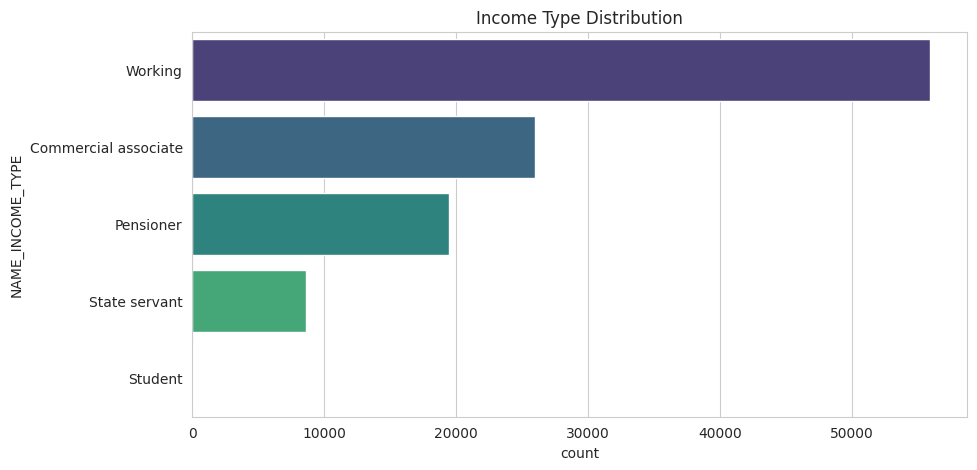

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=application,
    y='NAME_INCOME_TYPE',
    order=application['NAME_INCOME_TYPE'].value_counts().index,
    palette='viridis'
)

plt.title("Income Type Distribution")

plt.show()

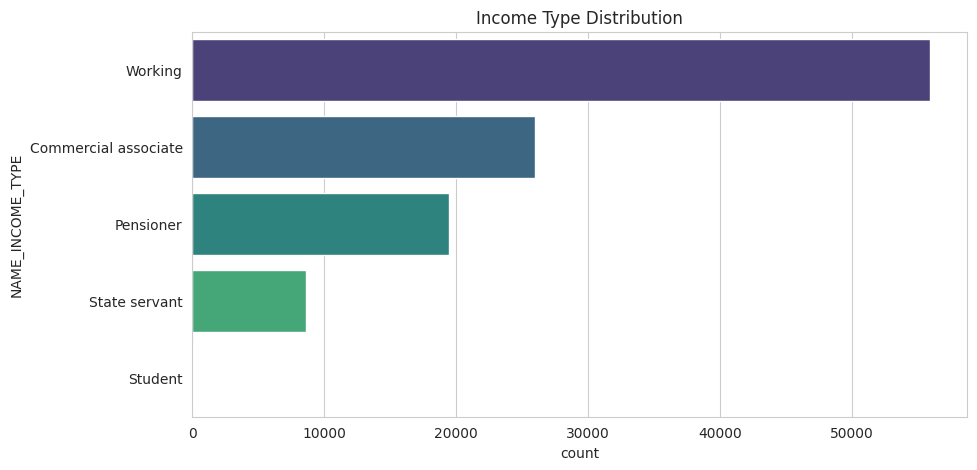

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=application,
    y='NAME_INCOME_TYPE',
    order=application['NAME_INCOME_TYPE'].value_counts().index,
    palette='viridis'
)

plt.title("Income Type Distribution")

plt.show()

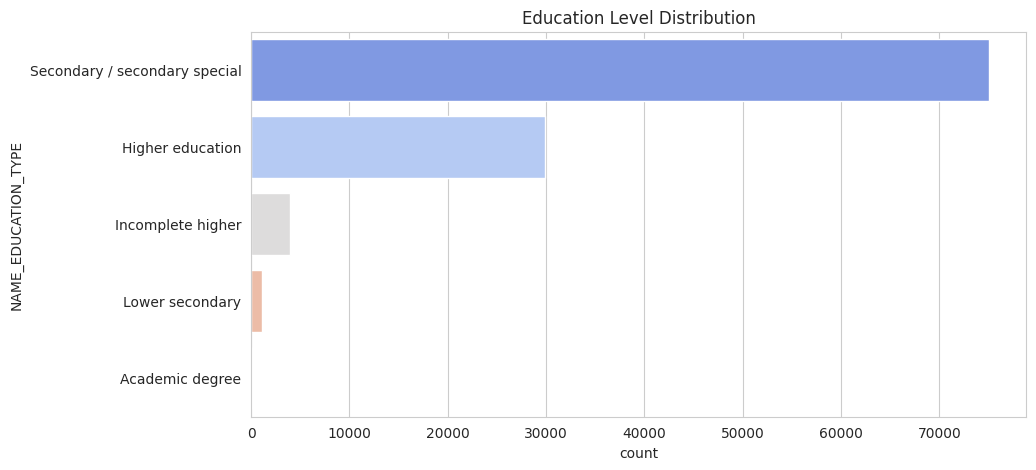

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=application,
    y='NAME_EDUCATION_TYPE',
    order=application['NAME_EDUCATION_TYPE'].value_counts().index,
    palette='coolwarm'
)

plt.title("Education Level Distribution")

plt.show()

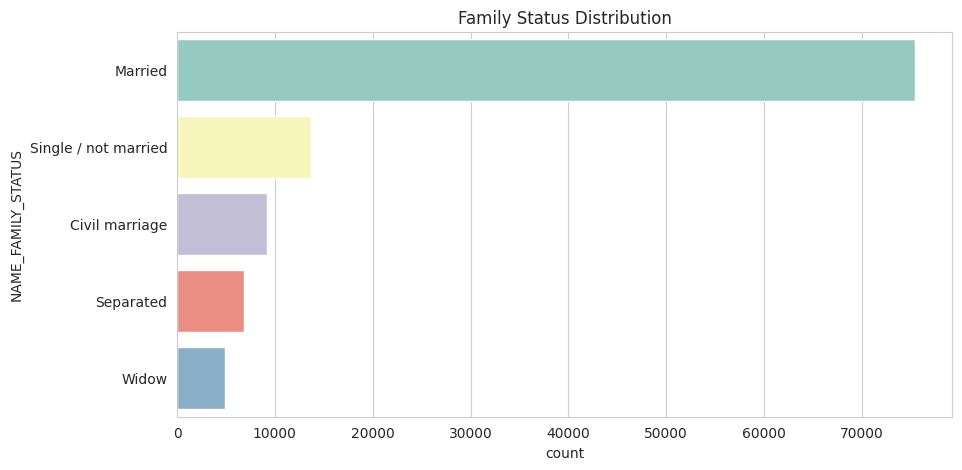

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=application,
    y='NAME_FAMILY_STATUS',
    order=application['NAME_FAMILY_STATUS'].value_counts().index,
    palette='Set3'
)

plt.title("Family Status Distribution")

plt.show()

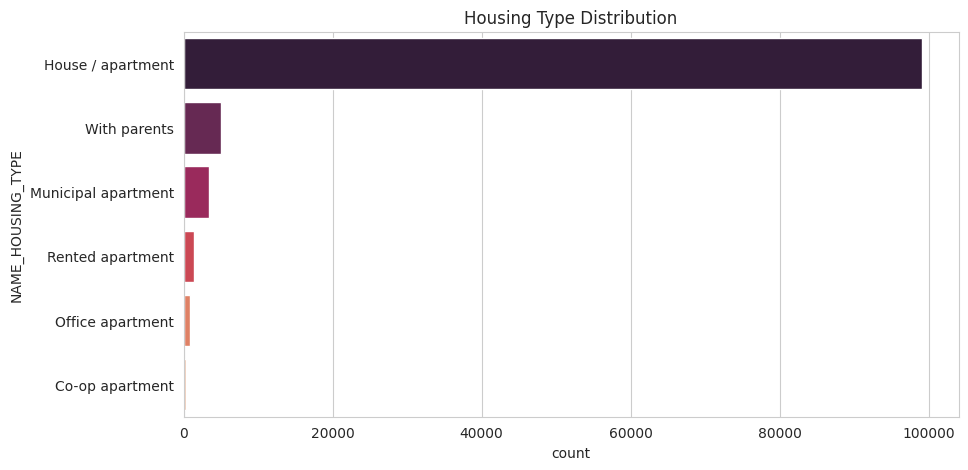

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=application,
    y='NAME_HOUSING_TYPE',
    order=application['NAME_HOUSING_TYPE'].value_counts().index,
    palette='rocket'
)

plt.title("Housing Type Distribution")

plt.show()

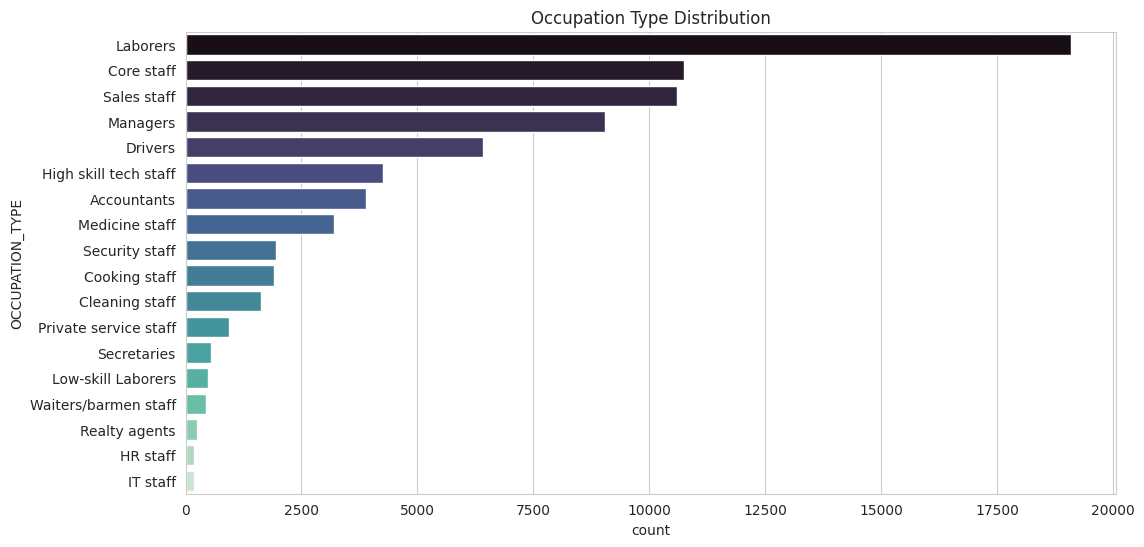

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=application,
    y='OCCUPATION_TYPE',
    order=application['OCCUPATION_TYPE'].value_counts().index,
    palette='mako'
)

plt.title("Occupation Type Distribution")

plt.show()

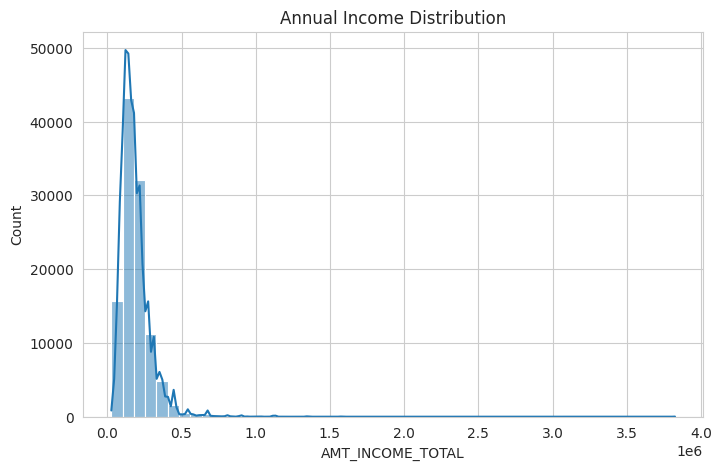

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    application['AMT_INCOME_TOTAL'],
    bins=50,
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

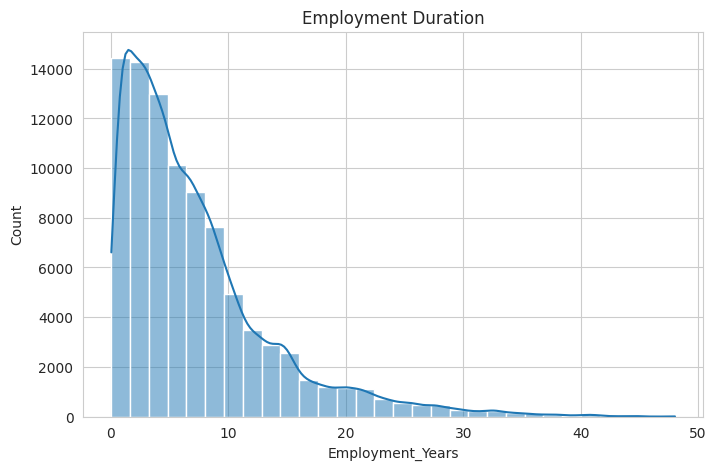

In [24]:
application['Employment_Years'] = (
    application['DAYS_EMPLOYED']
    .replace(365243, np.nan) * -1 / 365
)

plt.figure(figsize=(8,5))

sns.histplot(
    application['Employment_Years'].dropna(),
    bins=30,
    kde=True
)

plt.title("Employment Duration")

plt.show()



Multivariate Analysis

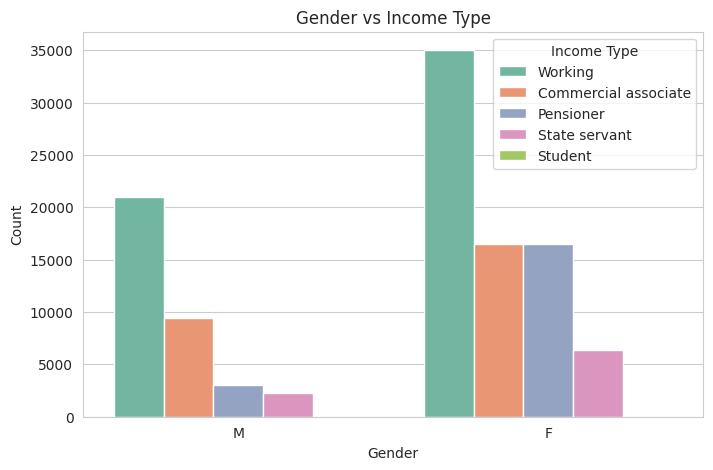

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=application,
    x='CODE_GENDER',
    hue='NAME_INCOME_TYPE',
    palette='Set2'
)

plt.title("Gender vs Income Type")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Income Type")
plt.show()

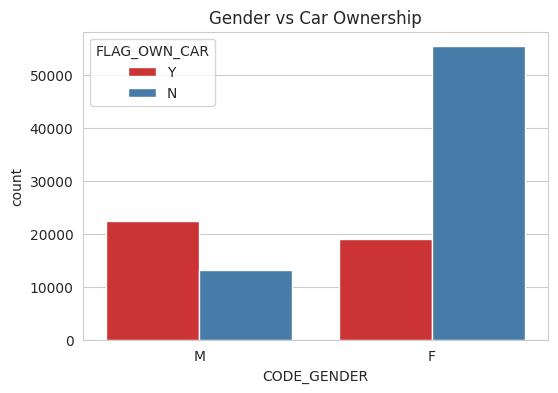

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=application,
    x='CODE_GENDER',
    hue='FLAG_OWN_CAR',
    palette='Set1'
)

plt.title("Gender vs Car Ownership")
plt.show()

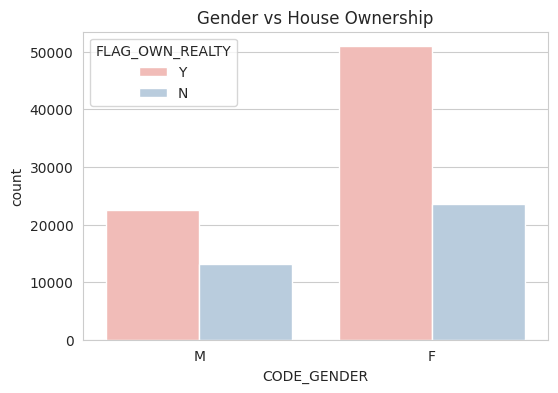

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=application,
    x='CODE_GENDER',
    hue='FLAG_OWN_REALTY',
    palette='Pastel1'
)

plt.title("Gender vs House Ownership")
plt.show()

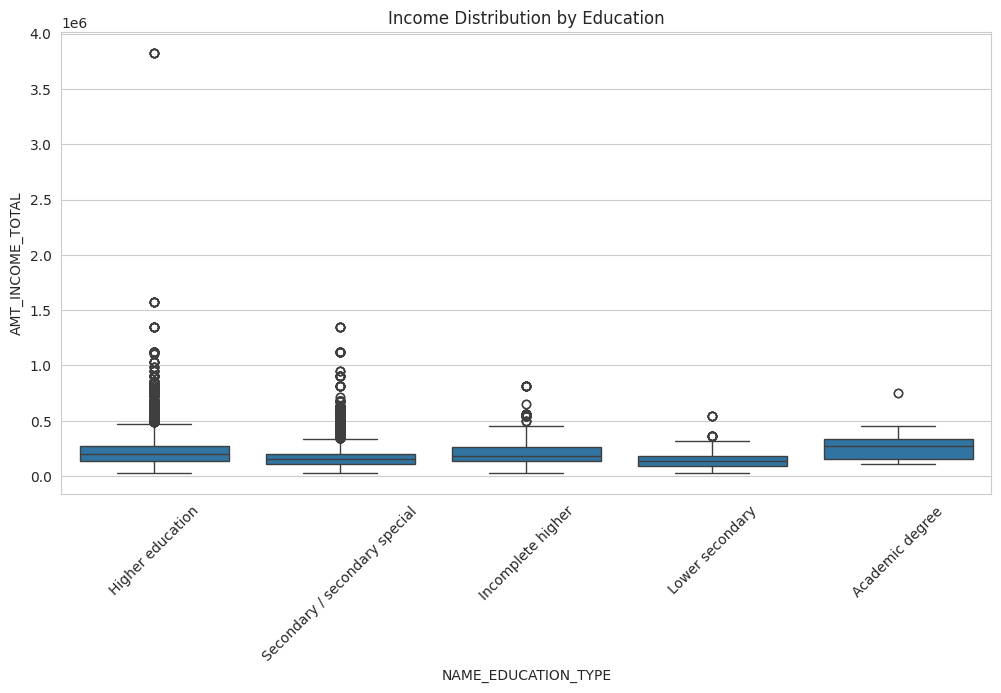

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=application,
    x='NAME_EDUCATION_TYPE',
    y='AMT_INCOME_TOTAL'
)

plt.xticks(rotation=45)

plt.title("Income Distribution by Education")

plt.show()

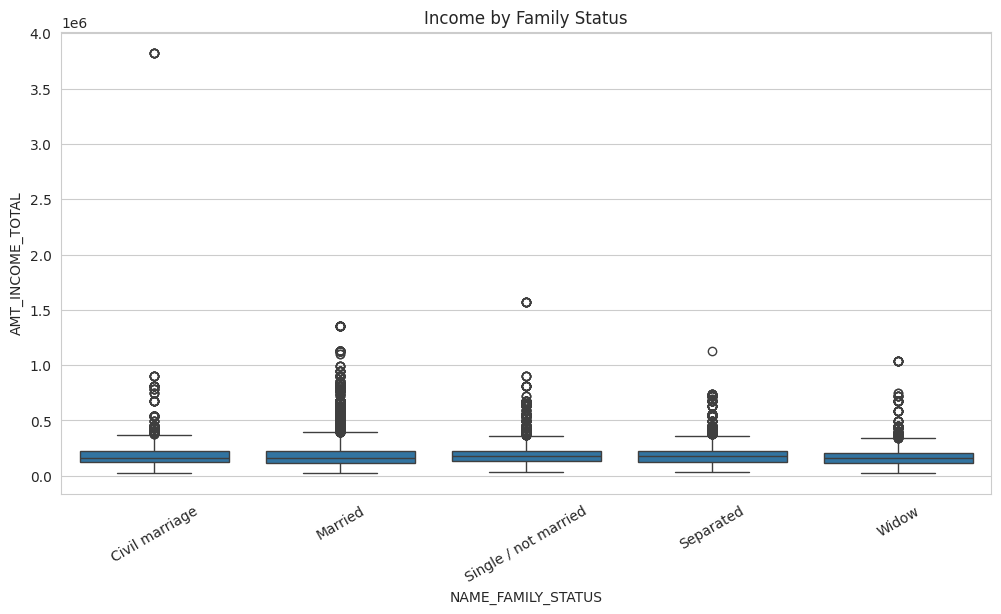

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=application,
    x='NAME_FAMILY_STATUS',
    y='AMT_INCOME_TOTAL'
)

plt.xticks(rotation=30)

plt.title("Income by Family Status")

plt.show()

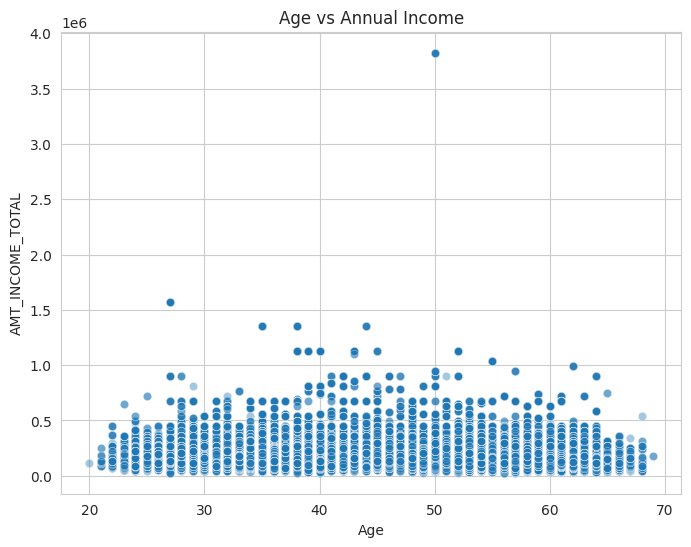

In [31]:
application['Age'] = application['DAYS_BIRTH'].apply(lambda x: abs(x)//365)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=application,
    x='Age',
    y='AMT_INCOME_TOTAL',
    alpha=0.4
)

plt.title("Age vs Annual Income")

plt.show()

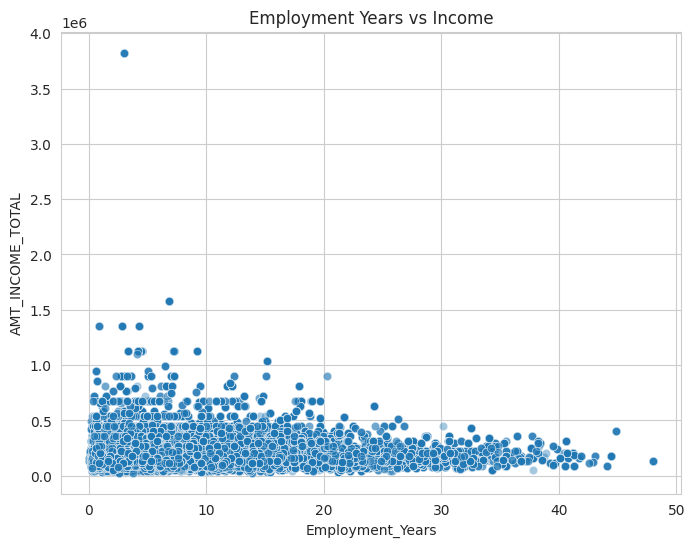

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=application,
    x='Employment_Years',
    y='AMT_INCOME_TOTAL',
    alpha=0.4
)

plt.title("Employment Years vs Income")

plt.show()

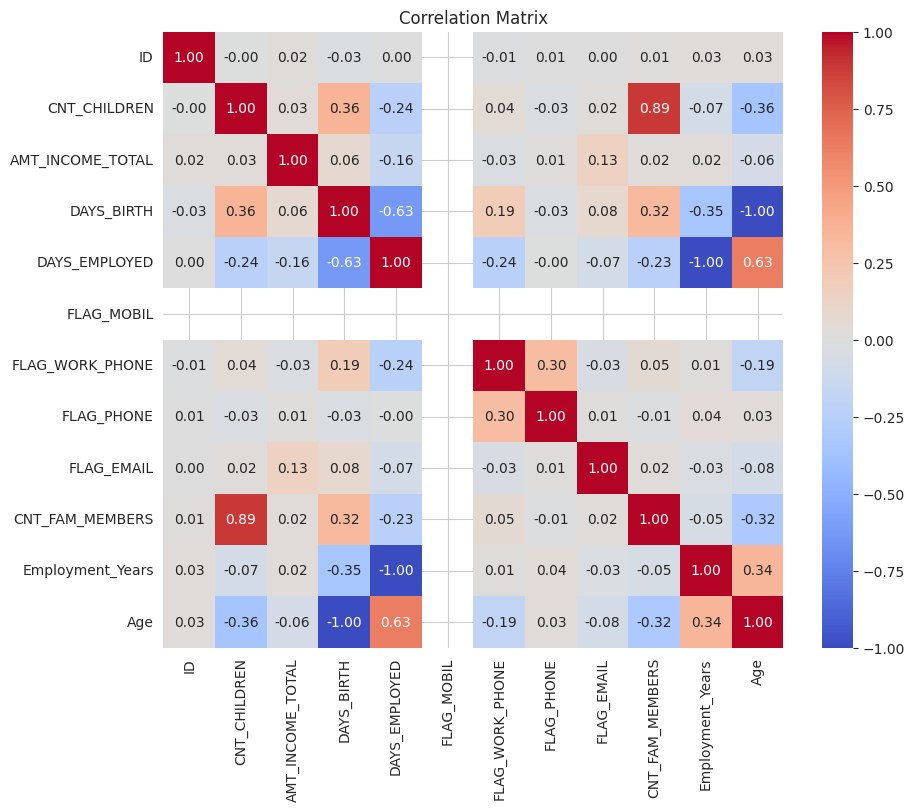

In [33]:
plt.figure(figsize=(10,8))

numeric_columns = application.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Descriptive Analysis

In [34]:
application.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,110084.0,5.380797e+06,400728.777171,5.008804e+06,5.115960e+06,5.267787e+06,5.429303e+06,6.840318e+06
CNT_CHILDREN,110084.0,4.351041e-01,0.739250,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,110084.0,1.859653e+05,104410.807210,2.700000e+04,1.215000e+05,1.575000e+05,2.250000e+05,3.825000e+06
DAYS_BIRTH,110084.0,-1.604581e+04,4206.744139,-2.520100e+04,-1.954800e+04,-1.559350e+04,-1.253000e+04,-7.489000e+03
DAYS_EMPLOYED,110084.0,6.248931e+04,140416.150761,-1.753100e+04,-3.088000e+03,-1.491000e+03,-3.610000e+02,3.652430e+05
FLAG_MOBIL,110084.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
FLAG_WORK_PHONE,110084.0,2.178882e-01,0.412813,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
FLAG_PHONE,110084.0,2.988718e-01,0.457766,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
FLAG_EMAIL,110084.0,8.300934e-02,0.275898,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
CNT_FAM_MEMBERS,110083.0,2.203764e+00,0.910556,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01


In [35]:
application.describe(include='object').T

,count,unique,top,freq
CODE_GENDER,110084,2,F,74432
FLAG_OWN_CAR,110084,2,N,68639
FLAG_OWN_REALTY,110084,2,Y,73378
NAME_INCOME_TYPE,110084,5,Working,55979
NAME_EDUCATION_TYPE,110084,5,Secondary / secondary special,75084
NAME_FAMILY_STATUS,110084,5,Married,75443
NAME_HOUSING_TYPE,110084,6,House / apartment,99062
OCCUPATION_TYPE,75749,18,Laborers,19097


In [36]:
missing = application.isnull().sum().to_frame(name='Missing Values')
missing

,Missing Values
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [37]:
duplicates = application.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [38]:
summary = pd.DataFrame({
    "Mean": application.mean(numeric_only=True),
    "Median": application.median(numeric_only=True),
    "Std Dev": application.std(numeric_only=True),
    "Minimum": application.min(numeric_only=True),
    "Maximum": application.max(numeric_only=True)
})

summary

,Mean,Median,Std Dev,Minimum,Maximum
ID,5.380797e+06,5.267787e+06,400728.777171,5.008804e+06,6.840318e+06
CNT_CHILDREN,4.351041e-01,0.000000e+00,0.739250,0.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,1.859653e+05,1.575000e+05,104410.807210,2.700000e+04,3.825000e+06
DAYS_BIRTH,-1.604581e+04,-1.559350e+04,4206.744139,-2.520100e+04,-7.489000e+03
DAYS_EMPLOYED,6.248931e+04,-1.491000e+03,140416.150761,-1.753100e+04,3.652430e+05
FLAG_MOBIL,1.000000e+00,1.000000e+00,0.000000,1.000000e+00,1.000000e+00
FLAG_WORK_PHONE,2.178882e-01,0.000000e+00,0.412813,0.000000e+00,1.000000e+00
FLAG_PHONE,2.988718e-01,0.000000e+00,0.457766,0.000000e+00,1.000000e+00
FLAG_EMAIL,8.300934e-02,0.000000e+00,0.275898,0.000000e+00,1.000000e+00
CNT_FAM_MEMBERS,2.203764e+00,2.000000e+00,0.910556,1.000000e+00,2.000000e+01
